# **Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb

# **Importing Data**

In [ ]:
# Load
df = pd.read_csv("/content/log.csv")

# Replace missing values
df.replace(-999.25, np.nan, inplace=True)

# Remove unrealistic values
df = df[df['GR'] < 200]         # remove extreme GR outliers
df = df[df['RILD'] < 1000]      # remove extreme resistivity
df = df[df['RHOB'] > 1.5]       # remove bad density values

df.dropna(inplace=True)

print("Final Shape:", df.shape)

# **Define Features & Target**

In [ ]:
features = ['RHOB','DPOR','CNLS','RILD','RLL3','SP','DCAL']
target = 'GR'

X = df[features]
y = df[target]

# **Train-Test Split (Simulating Cross-Well Generalization)**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# **Scale Data (Important for SVM & kNN)**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Model Training**

**1. Random Forest (Best for Logs)**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

**2. XGBoost**

In [ ]:
import xgboost as xgb

xgbr = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

xgbr.fit(X_train, y_train)
xgb_pred = xgbr.predict(X_test)

**3. SVM**

In [ ]:
from sklearn.svm import SVR

svm = SVR(kernel='rbf', C=100)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)

**4. k-NN**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

# **Model Evaluation**



In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

def evaluate(name, y_true, y_pred):
    print(f"{name}")
    print("R2:", r2_score(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("---------------")

evaluate("Random Forest", y_test, rf_pred)
evaluate("XGBoost", y_test, xgb_pred)
evaluate("SVM", y_test, svm_pred)
evaluate("kNN", y_test, knn_pred)

Random Forest
R2: 0.7617742646595179
RMSE: 17.34870514651394
---------------
XGBoost
R2: 0.7300164824186011
RMSE: 18.46891376789847
---------------
SVM
R2: 0.369991174709173
RMSE: 28.21279053363745
---------------
kNN
R2: 0.599711291696793
RMSE: 22.488443500284514
---------------


# **Plot Actual vs Predicted**

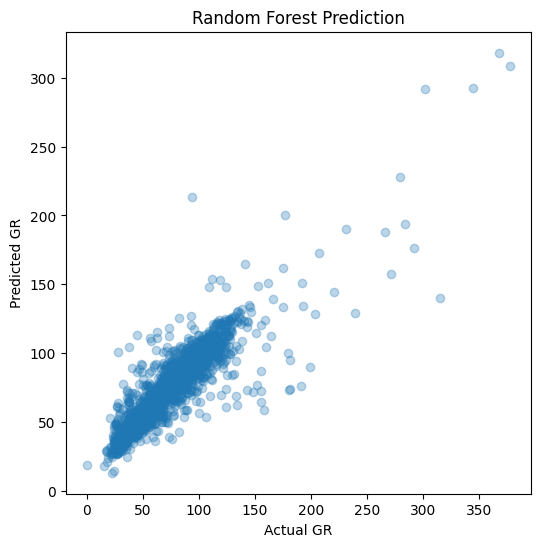

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred, alpha=0.3)
plt.xlabel("Actual GR")
plt.ylabel("Predicted GR")
plt.title("Random Forest Prediction")
plt.show()

# **Lithology Classification**

**Using GR cutoffs:**

In [ ]:
df['Lithology'] = np.where(df['GR'] < 60, 'Sand',
                    np.where(df['GR'] < 100, 'Silty Sand', 'Shale'))
df['Lithology']

,Lithology
0,Silty Sand
1,Sand
2,Sand
3,Sand
4,Sand
...,...
8734,Sand
8735,Sand
8736,Sand
8737,Sand


# **Hydrocarbon Zone Identification**

**Reservoir indicators:**

**Low GR**

**High Resistivity (RILD)**

**Moderate porosity (DPOR)**

In [ ]:
df['Hydrocarbon_Zone'] = np.where(
    (df['GR'] < 60) &
    (df['RILD'] > 20) &
    (df['DPOR'] > 10),
    1, 0)
df['Hydrocarbon_Zone']

,Hydrocarbon_Zone
0,0
1,1
2,1
3,1
4,1
...,...
8734,0
8735,0
8736,0
8737,0


# **Feature Importance**

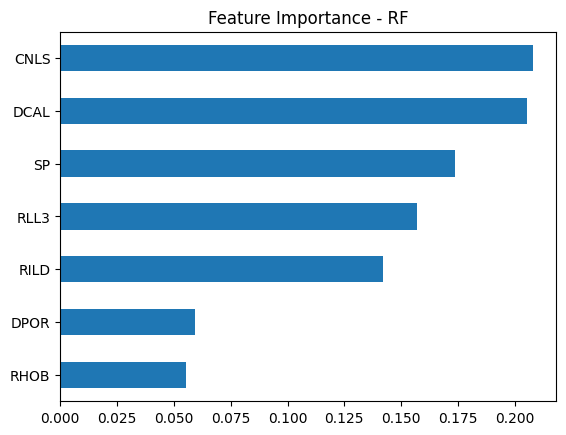

In [ ]:
importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance - RF")
plt.show()

# **correlation heatmap:**

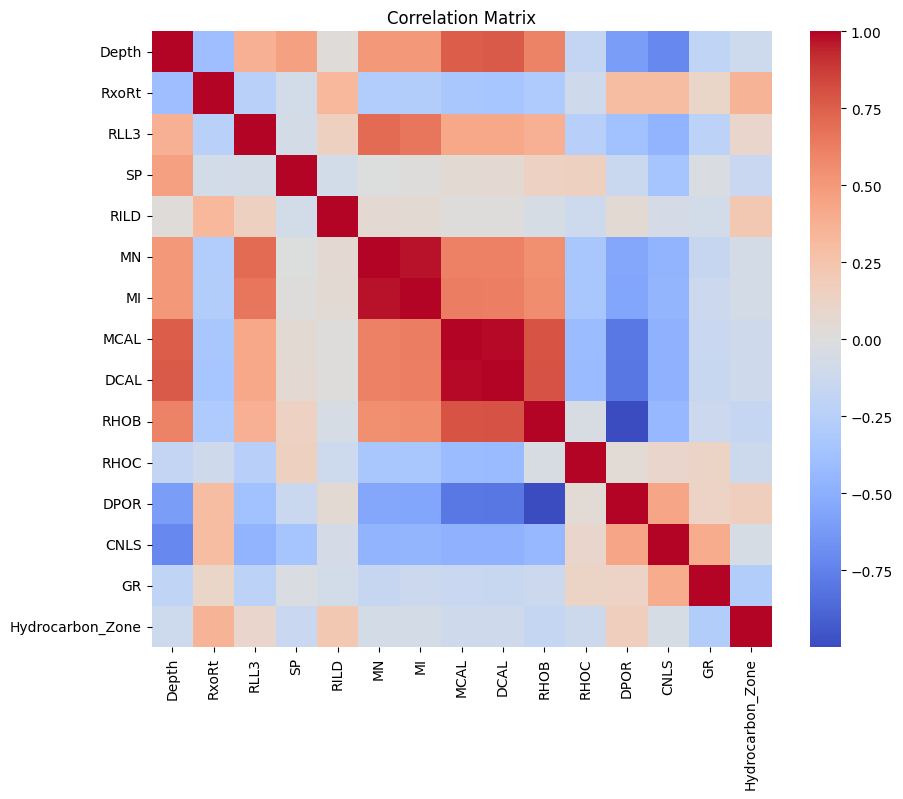

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()